# Создание модели

## Импорт библиотек

In [1]:
import sys
# Добавим папку проекта в список системных директорий, чтобы Python видел путь к папке rec_sys
sys.path.append("../../") 
# И модулю app
sys.path.append("../")

In [3]:
from pathlib import Path
import time
from datetime import timedelta
import json
from itertools import product
import pandas as pd
from annoy import AnnoyIndex
import pickle

from rectools import Columns
from rectools.dataset import Dataset
from rectools.models import (
    RandomModel,
    PopularModel, 
    PureSVDModel,
    ImplicitALSWrapperModel,
    ImplicitItemKNNWrapperModel,
    ImplicitBPRWrapperModel,
    LightFMWrapperModel,
)
from rectools.metrics import Precision, DebiasConfig, calc_metrics
from rectools.model_selection import TimeRangeSplitter, cross_validate
from rectools.visuals import MetricsApp

from implicit.als import AlternatingLeastSquares
from implicit.nearest_neighbours import (
    TFIDFRecommender,
    CosineRecommender,
    BM25Recommender,
)
from implicit.bpr import BayesianPersonalizedRanking

from lightfm import LightFM

from sklearn.preprocessing import MinMaxScaler

import optuna

from warnings import simplefilter

from rec_sys.utils.prepare_data import get_event_weight
from rec_sys.utils.constants import RECOMMENDATIONS_COUNT, SPLIT_DATE
from rec_sys.utils.helpers import display_exec_time
from rec_sys.utils.graphs import show_distribution_numeric_value, show_pie_by_dict

from rec_sys.app.classes import (
    SimilarItemsSeacher, 
    SimilarItemsRanker, 
    RecommenderSimilarItems,
)
from rec_sys.app.utils.constants import (
    ANNOY_VECTOR_SIZE, 
    ANNOY_METRIC, 
    SIMILAR_ITEMS_COUNT,
)

pd.set_option("display.max_colwidth", None)

%matplotlib inline

simplefilter("ignore")

In [4]:
# Путь к папке с данными
DATA_PATH = "../../data"

# Путь к папке с приложением
APP_PATH = "../app"

RANDOM_STATE = 42

## Загрузка данных

В файле с исследованием данных [02_eda.ipynb](./02_eda.ipynb) мы создали расширенную таблицу с событиями `events_advanced_data`.\
В файле с созданием признаков [03_feature_engineering.ipynb](./03_feature_engineering.ipynb) мы создали таблицы с данными пользователей (`users_data`) и товаров (`items_data`).\
Загрузим их.

In [5]:
# Расширенная таблица с данными о событиях
events_data = pd.read_csv(f"{DATA_PATH}/events_advanced_data.csv")
# Признак даты переведем в тип datetime
events_data["event_datetime"] = pd.to_datetime(events_data["event_datetime"])

# Таблица с данными пользователей
users_data = pd.read_csv(f"{DATA_PATH}/users_data.csv")

# Таблица с данными товаров
items_data = pd.read_csv(f"{DATA_PATH}/items_data.csv")

Посмотрим на первые строки таблиц.

In [6]:
events_data.head(3)

,visitorid,event,itemid,transactionid,event_datetime,date,year,month,day,day_of_week,hour,minute,is_transaction,time_of_day,update_stage,available,price,is_price_0,categoryid,root_categoryid
0,693516,addtocart,297662,NaN,2015-05-03 03:00:04.384,2015-05-03,2015,5,3,6,3,0,False,3-7,0,1.0,14280.0,False,NaN,NaN
1,829044,view,60987,NaN,2015-05-03 03:00:11.289,2015-05-03,2015,5,3,6,3,0,False,3-7,0,0.0,204120.0,False,NaN,NaN
2,652699,view,252860,NaN,2015-05-03 03:00:13.048,2015-05-03,2015,5,3,6,3,0,False,3-7,0,NaN,NaN,False,NaN,NaN


In [7]:
users_data.head(3)

,visitorid,adds_count,trans_cout,views_count,min_items_in_trans,mean_items_in_trans,max_items_in_trans,adds_in_day_0,trans_in_day_0,views_in_day_0,...,trans_in_cat_803,trans_in_cat_859,trans_in_cat_1224,trans_in_cat_1452,trans_in_cat_1482,trans_in_cat_1490,trans_in_cat_1532,trans_in_cat_1579,trans_in_cat_1600,trans_in_cat_1698
0,3,0,0,0,0.0,0.0,0.0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5,0,0,0,0.0,0.0,0.0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,7,0,0,0,0.0,0.0,0.0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
items_data.head(3)

,itemid,is_top_10,trans_in_day_0,trans_in_day_1,trans_in_day_2,trans_in_day_3,trans_in_day_4,trans_in_day_5,trans_in_day_6,trans_in_time_12-16,...,c_291,c_292,c_293,c_294,c_295,c_296,c_297,c_298,c_299,c_300
0,0,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.910129e-07,0.000138,-0.000066,-0.000154,-0.000102,0.000198,-0.000086,-0.000079,0.000069,-0.000041
1,1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.069498e-07,0.000179,-0.000086,-0.000200,-0.000131,0.000256,-0.000111,-0.000103,0.000089,-0.000054
2,2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.813608e-03,-0.001189,0.000129,0.006457,0.007567,-0.001437,0.004260,0.004028,0.006627,0.000051


## Функции

In [9]:
# В Columns содержатся стандартные имена столбцов для таблиц, которые ипользуются в rectools.
# Выведем для справки их значения.
Columns.__dict__

mappingproxy({'__module__': 'rectools.columns',
              '__doc__': 'Fixed column names for tables that contain interactions and recommendations.',
              'User': 'user_id',
              'Item': 'item_id',
              'TargetItem': 'target_item_id',
              'Weight': 'weight',
              'Datetime': 'datetime',
              'Rank': 'rank',
              'Score': 'score',
              'Model': 'model',
              'Split': 'i_split',
              'UserItem': ['user_id', 'item_id'],
              'Interactions': ['user_id', 'item_id', 'weight', 'datetime'],
              'Recommendations': ['user_id', 'item_id', 'score', 'rank'],
              'RecommendationsI2I': ['target_item_id',
               'item_id',
               'score',
               'rank'],
              '__dict__': <attribute '__dict__' of 'Columns' objects>,
              '__weakref__': <attribute '__weakref__' of 'Columns' objects>})

In [10]:
def get_normalized_data(
    source_data: pd.DataFrame, 
    index_name: str,
    should_reset_index: bool,
) -> pd.DataFrame:
    """Нормализует данные в таблице

    Args:
        source_data (pd.DataFrame): исходная таблица
        index_name (str): поле, которое определяет уникальную строку 
                          и которое не нужно нормализовывать
        should_reset_index (bool): нужно ли сбросить индекс

    Returns:
        pd.DataFrame: таблица с нормализованными данными
    """
    data = source_data.copy()
    
    min_max_scaler = MinMaxScaler()

    prepared_data = data.set_index(index_name)

    normalized_values = min_max_scaler.fit_transform(prepared_data)

    normalized_data = pd.DataFrame(
        data=normalized_values,
        columns=prepared_data.columns,
        index=prepared_data.index
    )

    if (should_reset_index):
        normalized_data.reset_index(inplace=True)
    
    return normalized_data

In [11]:
def get_formatted_ratings_data(data: pd.DataFrame) -> pd.DataFrame:
    """Переводит таблицу с событиями в формат, ожидаемый в библиотеке rectools

    Args:
        data (pd.DataFrame): исходная таблица с событиями

    Returns:
        pd.DataFrame: преобразованная таблица, подходящая для использования в rectools
    """

    rating_data = data.copy()
    rating_data[Columns.Weight] = rating_data["event"].apply(get_event_weight)
    rating_data.rename(columns={
        "visitorid": Columns.User,
        "itemid": Columns.Item,
        "event_datetime": Columns.Datetime,
    }, inplace=True)
    columns = [Columns.User, Columns.Item, Columns.Weight, Columns.Datetime]
    
    result_rating_data = rating_data[columns]
    result_rating_data.reset_index(drop=True, inplace=True)
    
    return result_rating_data

In [12]:
def get_formatted_features_data(
    data: pd.DataFrame, 
    id_feature_name: str
) -> pd.DataFrame:
    """Переводит таблицы с данными пользователей и товаров в формат,
    ожидаемый в rectools

    Args:
        data (pd.DataFrame): исходная таблица с данными
        id_feature_name (str): имя признака с идентификатором (товара или пользователя)

    Returns:
        pd.DataFrame: преобразованная для rectools таблица
    """
    # Имена колонок с признками, которые будем переводить из столбцов в строки
    feature_names = list(data.columns)
    feature_names.remove(id_feature_name)

    # Сюда для каждого из признаков будем собирать таблицы из 2-х колонок
    # идентификатор (пользователя или товара) - значение соответствующего признака
    feature_frames = []

    # Итерируемся по именам признаков
    for feature in feature_names:
        # Составляем датафрейм из строк только данного признака
        feature_frame = data.reindex(columns=[id_feature_name, feature])
        # Переименовываем колонки
        feature_frame.columns = ["id", "value"]
        # Добавляем колонку с названием признака
        feature_frame["feature"] = feature
        # Сохраняем полученный датайрейм со значениями только данного признака
        feature_frames.append(feature_frame)
    
    # Объединяем по вертикали все собранные датафреймы для признаков
    features_data = pd.concat(feature_frames)
    features_data.reset_index(drop=True, inplace=True)
    
    return features_data

## Подготовка таблиц для модели

### Разделение выборки на обучающую и тестовую

В файле с созданием признаков [03_feature_engineering.ipynb](./03_feature_engineering.ipynb) \
мы определили дату для разделения обучающей и тестовой выборки.\
И поместили ее в константу `SPLIT_DATE` в файл [utils/constants.py](../utils/constants.py).\
Здесь используем ее.

In [13]:
mask_before_split_date = events_data["event_datetime"] < SPLIT_DATE

events_train_data = events_data[mask_before_split_date] 
events_test_data = events_data[~mask_before_split_date]

print("Размер обучающей выборки:", events_train_data.shape)
print("Размер тестовой выборки:", events_test_data.shape)

Размер обучающей выборки: (1916993, 20)
Размер тестовой выборки: (838648, 20)


### Преобразование таблицы `events_train_data`

Модели, в которых применяется матричная факторизация, показывают более хорошие результаты,\
если матрица взаимодействий пользователей с объектами "плотная".\
То есть, по каждому пользователю достаточно информации о его взаимодействиях, \
по которой можно уловить закономерности.

Поэтому из тренировочной выборки мы выделим данные более активных пользователей.\
И далее посмотрим, как на этих данных покажут себя подобные модели (`ALS` и `LightFm`).

Мы будем использовать разные алгоритмы построения рекомендаций \
для более активных пользователей, менее активных, а также неизвестных.

In [14]:
# Таблица с количеством взаимодействий каждого пользователя из тренировочной выборки
user_events_volume = events_train_data.groupby("visitorid").agg(
    events_count=("event", "count")
).reset_index()

user_events_volume.sort_values("events_count")

,visitorid,events_count
0,3,1
593890,859657,1
593891,859659,1
593892,859660,1
593893,859661,1
...,...,...
198195,286616,2252
256952,371606,2345
112949,163561,2410
366619,530559,2538


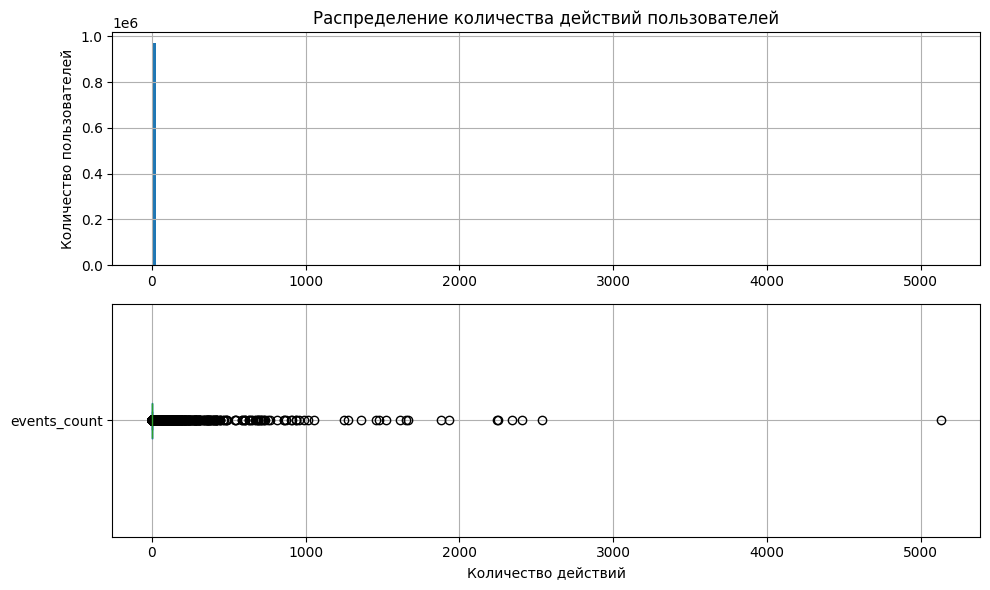

**Характеристики распределения:**

count    972459.000000
mean          1.971284
std          11.271695
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max        5129.000000
Name: events_count, dtype: float64

In [15]:
# Посмотрим на распределение количества действий пользователей
show_distribution_numeric_value(
    user_events_volume["events_count"],
    "Распределение количества действий пользователей",
    "Количество действий",
    "Количество пользователей"
)

Уберем самого активного пользователя (более 5000 действий) \
и пользователей с небольшим количеством действий.

Опытным путем выяснено, что на текущих данных модель ALS начинает показывать хорошие результаты,\
при минимальном количестве действий пользователя от 15-ти.

Поскольку дальше мы собираемся создать 3 алгоритма рекомендаций для разных типов пользователей,\
то нам нужно выделить 3 тренировочные выборки.

1. Выборка активных пользователей с удаленными экстремальными значениями. \
Дадим этой группе условное название `normal`.
    - назовем таблицу `events_train_normal_data`

2. Выборка пользователей, которые не вошли в предыдущую (мало активные + экстремально активные).\
Дадим этой группе условное название `extremal`.
    - назовем таблицу `events_train_extremal_data`

3. Вся тренировочная выборка. \
Она будет нужна для обучения моделей для генерации рекомендаций неизвестным (холодным) пользователям 
на основе популярности товаров.\
Дадим группе холодных пользователей условное название `cold`.
    - назовем таблицу `events_train_all_data`

> Далее включения в названия `normal`, `extremal`, `all`, `cold` \
будем использовать соответственно тем смыслам, которые были описаны выше.

Для каждой тренировочной выборки составим свою тестовую.

1. `events_test_normal_data` - сюда войдут пользователи из тестовой части, \
которые есть в `events_train_normal_data`.

2. `events_test_extremal_data` - сюда войдут пользователи из тестовой части, \
которые есть в `events_train_extremal_data`.

3. `events_test_cold_data` - сюда войдут "холодные" пользователи из тестовой части. \
То есть те, которые не упоминаются ни в одной из тренировочных.

> **Примечание**. Поскольку в выборку пользователей с "экстремальной" активностью \
у нас войдут мало активные пользователи с количеством действий <= 15 \
и только один гипер активный, то далее будем часто упомниать ее, \
как выборку с мало активными пользователями.

In [15]:
# Тренировочная выборка со всеми пользователями
events_train_all_data = events_train_data.copy()

In [16]:
# Нижний и верхний пределы количества действий пользователей.
LOWER_LIMIT_EVENTS_COUNT = 15
UPPER_LIMIT_EVENTS_COUNT = 4000

# Выделим id пользователей с малым или слишком большим кол-вом действий
mask_users_with_extremal_events_count = \
    (user_events_volume["events_count"] <= LOWER_LIMIT_EVENTS_COUNT) | \
    (user_events_volume["events_count"] >= UPPER_LIMIT_EVENTS_COUNT)

user_ids_with_extremal_events_count = set(
    user_events_volume[mask_users_with_extremal_events_count]["visitorid"].unique()
)

# Уберем экстремальных пользователей
events_train_normal_data = events_train_data.drop(
    index=events_train_data[
        events_train_data["visitorid"].isin(user_ids_with_extremal_events_count)
    ].index,
    axis=0
)

# И выделим экстремальных пользователей
events_train_extremal_data = events_train_data.drop(
    index=events_train_data[
        ~events_train_data["visitorid"].isin(user_ids_with_extremal_events_count)
    ].index,
    axis=0
)

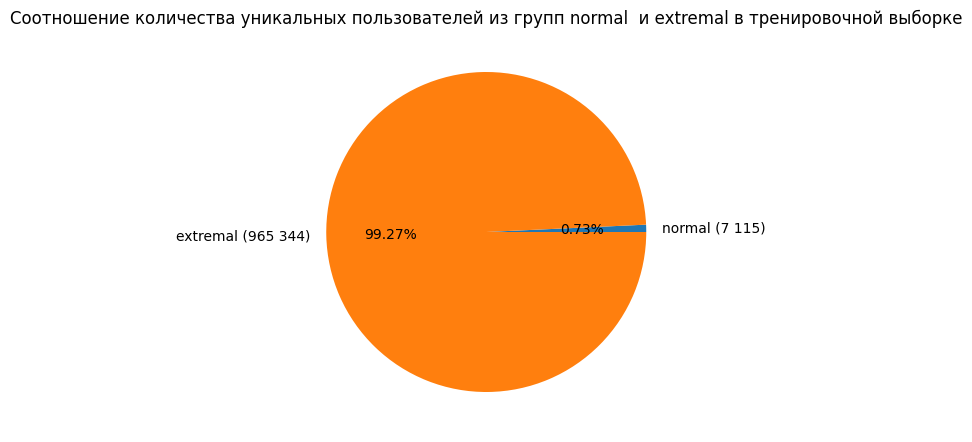

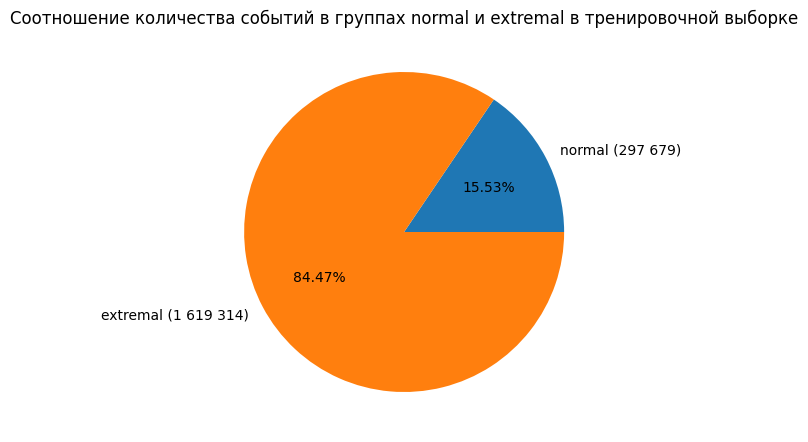

In [20]:
show_pie_by_dict(
    {
        "normal": events_train_normal_data["visitorid"].nunique(),
        "extremal": events_train_extremal_data["visitorid"].nunique(),
    },
    "Соотношение количества уникальных пользователей из групп normal  и extremal в тренировочной выборке"
)
show_pie_by_dict(
    {
        "normal": len(events_train_normal_data),
        "extremal": len(events_train_extremal_data),
    },
    "Соотношение количества событий в группах normal и extremal в тренировочной выборке"
)

При передаче данных в модели, в которых применяется матричная факторизация,\
необходимо передавать данные, в которых соблюдается взаимно однозначное соответствие\
идентификаторов пользователей и товаров.

Выделим общие идентификаторы.

In [21]:
common_train_normal_items_ids = set(items_data["itemid"].unique()) & \
                         set(events_train_normal_data["itemid"].unique())
                         
print(
    "Количество общих товаров:",
    len(common_train_normal_items_ids)
)

Количество общих товаров: 50334


Оставим в тренировочной таблице только данные с общими идентификаторами.

In [22]:
events_train_normal_data = events_train_normal_data[
    events_train_normal_data["itemid"].isin(common_train_normal_items_ids)
]
events_train_normal_data.shape

(286678, 20)

Преобразуем таблицу к формату, ожидаемому в `rectools`.

In [23]:
ratings_train_normal_data = get_formatted_ratings_data(events_train_normal_data)
ratings_train_normal_data.head(3)

,user_id,item_id,weight,datetime
0,1222911,278143,1,2015-05-03 03:05:25.414
1,954142,116380,1,2015-05-03 03:05:48.199
2,954142,24357,1,2015-05-03 03:07:33.281


In [24]:
ratings_train_all_data = get_formatted_ratings_data(events_train_all_data)
ratings_train_all_data.head(3)

,user_id,item_id,weight,datetime
0,693516,297662,3,2015-05-03 03:00:04.384
1,829044,60987,1,2015-05-03 03:00:11.289
2,652699,252860,1,2015-05-03 03:00:13.048


### Преобразование таблицы `events_test_data`

Выделим 3 тестовые выборки, как было описано выше.

In [25]:
train_normal_users_ids = set(events_train_normal_data["visitorid"].unique())
train_extremal_users_ids = set(events_train_extremal_data["visitorid"].unique())

mask_users_from_train_normal = events_test_data["visitorid"].isin(train_normal_users_ids)
mask_users_from_train_extremal = events_test_data["visitorid"].isin(train_extremal_users_ids)

events_test_normal_data = events_test_data[mask_users_from_train_normal]
events_test_extremal_data = events_test_data[mask_users_from_train_extremal]

all_train_user_ids = set(events_train_all_data["visitorid"].unique())
mask_users_from_train_all = events_test_data["visitorid"].isin(all_train_user_ids)
events_test_cold_data = events_test_data[~mask_users_from_train_all]

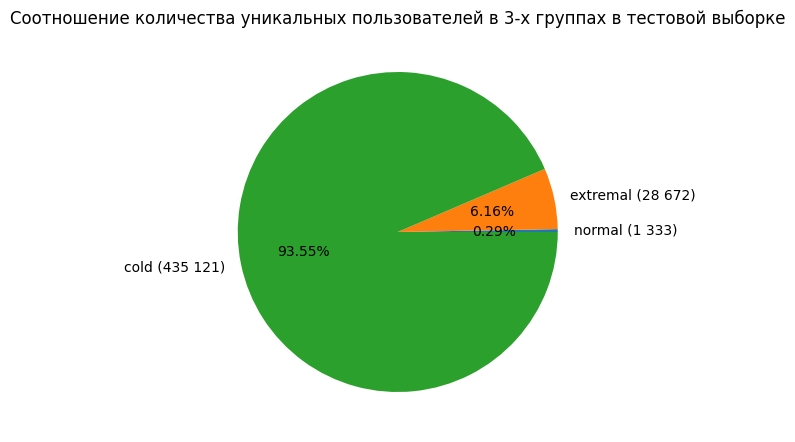

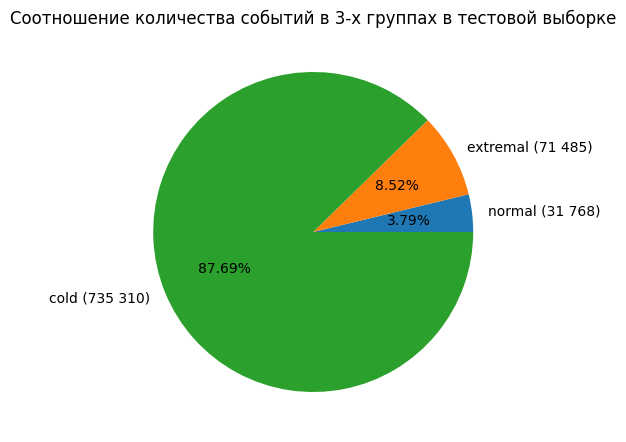

In [27]:
show_pie_by_dict(
    {
        "normal": events_test_normal_data["visitorid"].nunique(),
        "extremal": events_test_extremal_data["visitorid"].nunique(),
        "cold": events_test_cold_data["visitorid"].nunique(),
    },
    "Соотношение количества уникальных пользователей в 3-х группах в тестовой выборке"
)
show_pie_by_dict(
    {
        "normal": len(events_test_normal_data),
        "extremal": len(events_test_extremal_data),
        "cold": len(events_test_cold_data),
    },
    "Соотношение количества событий в 3-х группах в тестовой выборке"
)

Преобразуем таблицы в формат, ожидаемый в `rectools`.

In [ ]:
ratings_test_normal_data = get_formatted_ratings_data(events_test_normal_data)

ratings_test_normal_data.head(3)

,user_id,item_id,weight,datetime
0,580290,322341,1,2015-08-02 03:01:14.469
1,580290,9877,1,2015-08-02 03:01:51.113
2,1357576,60818,1,2015-08-02 03:01:54.842


In [25]:
ratings_test_extremal_data = get_formatted_ratings_data(events_test_extremal_data)

ratings_test_extremal_data.head(3)

,user_id,item_id,weight,datetime
0,1017234,158237,1,2015-08-02 03:00:01.730
1,73836,297765,1,2015-08-02 03:00:02.314
2,3673,106720,1,2015-08-02 03:00:14.944


In [26]:
ratings_test_cold_data = get_formatted_ratings_data(events_test_cold_data)

ratings_test_cold_data.head(3)

,user_id,item_id,weight,datetime
0,1097496,132469,1,2015-08-02 03:00:08.161
1,1372267,208262,1,2015-08-02 03:01:06.403
2,107680,219512,1,2015-08-02 03:01:13.519


### Преобразование таблицы `users_data`

Таблицу с данными пользователей нам нужно будет использовать в моделях с матричной факторизацией.\
Поэтому в ней должны остаться только те пользователи, которые есть в таблице `events_train_normal_data`.

In [27]:
# Для передачи в dense-формат датасета столбец с id пользователя должен иметь стандартное имя
users_data.rename(columns={"visitorid": Columns.User}, inplace=True)

# В таблице с данными пользователей оставим только тех, которые есть в тренировочной выборке.
users_normal_data = users_data[
    users_data[Columns.User].isin(train_normal_users_ids)
]

users_normal_data.shape

(7071, 66)

In [28]:
users_normal_data.head(3)

,user_id,adds_count,trans_cout,views_count,min_items_in_trans,mean_items_in_trans,max_items_in_trans,adds_in_day_0,trans_in_day_0,views_in_day_0,...,trans_in_cat_803,trans_in_cat_859,trans_in_cat_1224,trans_in_cat_1452,trans_in_cat_1482,trans_in_cat_1490,trans_in_cat_1532,trans_in_cat_1579,trans_in_cat_1600,trans_in_cat_1698
49,75,0,0,0,0.0,0.0,0.0,0,0,10,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
111,172,0,0,0,0.0,0.0,0.0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
367,549,0,0,0,0.0,0.0,0.0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Нормализуем данные в таблице данных пользователей.

In [29]:
users_normal_data = get_normalized_data(
    users_normal_data, 
    index_name=Columns.User, 
    should_reset_index=True,
)

In [30]:
# Приведем данные известных пользователей в формат, ожидаемый в rectools
users_normal_features = get_formatted_features_data(users_normal_data, Columns.User)

users_normal_features.head()

,id,value,feature
0,75,0.0,adds_count
1,172,0.0,adds_count
2,549,0.0,adds_count
3,648,0.0,adds_count
4,1346,0.0,adds_count


In [31]:
# Посмотрим на типы столбцов
users_normal_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 459615 entries, 0 to 459614
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       459615 non-null  int64  
 1   value    459615 non-null  float64
 2   feature  459615 non-null  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 10.5+ MB


### Преобразование таблицы `items_data`

In [32]:
# Вспомним содержимое таблицы
items_data.head(3)

,itemid,is_top_10,trans_in_day_0,trans_in_day_1,trans_in_day_2,trans_in_day_3,trans_in_day_4,trans_in_day_5,trans_in_day_6,trans_in_time_12-16,...,c_291,c_292,c_293,c_294,c_295,c_296,c_297,c_298,c_299,c_300
0,0,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.910129e-07,0.000138,-0.000066,-0.000154,-0.000102,0.000198,-0.000086,-0.000079,0.000069,-0.000041
1,1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.069498e-07,0.000179,-0.000086,-0.000200,-0.000131,0.000256,-0.000111,-0.000103,0.000089,-0.000054
2,2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.813608e-03,-0.001189,0.000129,0.006457,0.007567,-0.001437,0.004260,0.004028,0.006627,0.000051


Данные о товарах также нужны для моделей с использованием матричной факторизации.\
Поэтому отделим данные о товарах, которые есть в таблице `events_train_normal_data`.

In [33]:
# Для передачи в dense-формат датасета столбец с id товара должен иметь стандартное имя
items_data.rename(columns={"itemid": Columns.Item}, inplace=True)

# Выделим в отдельную таблицу товары, которые есть в тренировочной выборке 
train_normal_items_ids = set(events_train_normal_data["itemid"].unique())

items_normal_data = items_data[
    items_data[Columns.Item].isin(train_normal_items_ids)
]

# Нормализуем данные в таблице товаров
items_normal_data = get_normalized_data(
    items_normal_data,
    index_name=Columns.Item,
    should_reset_index=True,
)

In [34]:
# Приведем данные товаров к формату, ожидаемому в rectools
items_normal_features = get_formatted_features_data(items_normal_data, Columns.Item)

items_normal_features.head(3)

,id,value,feature
0,6,0.0,is_top_10
1,15,0.0,is_top_10
2,16,0.0,is_top_10


In [35]:
# Посмотрим на типы столбцов
items_normal_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15804876 entries, 0 to 15804875
Data columns (total 3 columns):
 #   Column   Dtype  
---  ------   -----  
 0   id       int64  
 1   value    float64
 2   feature  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 361.7+ MB


### Создание объектов Dataset

In [36]:
# Датасет для моделей, которые не поддерживают features пользователей и товаров
normal_dataset = Dataset.construct(ratings_train_normal_data)

In [37]:
all_dataset = Dataset.construct(ratings_train_all_data)

In [38]:
# Датасет для моделей, которые поддерживают features пользователей и товаров
dense_features_normal_dataset = Dataset.construct(
    ratings_train_normal_data,
    
    user_features_df=users_normal_data,
    make_dense_user_features=True,
    
    item_features_df=items_normal_data,
    make_dense_item_features=True,
)

## Прогноз для активных пользователей

Библиотека `rectools` позволяет рассчитывать значения метрик сразу для нескольких моделей с использованием кроссвалидации ([пример в документации](https://rectools.readthedocs.io/en/latest/examples/2_cross_validation.html)).\
Воспользуемся этой возможностью и посмотрим, какие модели показывают более лучший результат на наших данных.

Процесс расчета разобьем на 2 части.\
В первой посчитаем метрики без использования факторов (`features`) пользователей и товаров.\
Во второй рассчитаем метрики для тех моделей, которые могут их использовать.

Потом объединим результаты и выберем лучшую модель.

### Подготовка общего сплитера

Посмотрим, за какой период у нас есть данные \
и какие промежутки мы можем взять для кроссвалидации.

In [62]:
print(
    "Данные в тренировочной выборке представлены за даты с",
    ratings_train_normal_data["datetime"].min().date(),
    "по",
    ratings_train_normal_data["datetime"].max().date()
)
print(
    "Что составляет:",
    str(ratings_train_normal_data["datetime"].max() - ratings_train_normal_data["datetime"].min())
)

Данные в тренировочной выборке представлены за даты с 2015-05-03 по 2015-08-02
Что составляет: 90 days 23:51:48.164000


> Таким образом, для кроссвалидации мы можем взять 3 промежутка по 30 дней.

In [63]:
SPLITS_COUNT = 3
TEST_SIZE = "30D"

splitter = TimeRangeSplitter(
    test_size=TEST_SIZE,
    n_splits=SPLITS_COUNT,
    filter_already_seen=True,
    filter_cold_items=True,
    filter_cold_users=True,
)

# Посмотрим на даты сплитов
splitter.get_test_fold_borders(normal_dataset.interactions)

[(Timestamp('2015-05-05 00:00:00'), Timestamp('2015-06-04 00:00:00')),
 (Timestamp('2015-06-04 00:00:00'), Timestamp('2015-07-04 00:00:00')),
 (Timestamp('2015-07-04 00:00:00'), Timestamp('2015-08-03 00:00:00'))]

### Словарь с метрикой

В тестовой выборке могут встречаться пользователи с экстремально высоким или низким количеством взаимодейстий.\
Иными словами, такие данные являются выбросами и влияют на подсчет метрики.

Модели, которые основываются на популярности товаров, будут выигрывать на пользователях со слишком большой активностью.

В библиотеке `rectools` реализован параметр `debias_config` для передачи в объект для подсчета метрики.\
Он принимает параметры, по которым пользователи с экстремальными параметрами будут удалятся из датасета перед подсчетом метрики.\
[Пример использования `debias_config` в документации](https://rectools.readthedocs.io/en/latest/examples/8_debiased_metrics.html).

Используем ниже этот параметр.

In [43]:
# Будем считать 2 метрики:
metrics = {
    # Обычная метрика precision@3
    "precision@3": Precision(k=RECOMMENDATIONS_COUNT),
    
    # Метрика precision@3, рассчитанная на тестовой выборке с удаленными выбросами
    "precision@3_debiased": Precision(
        k=RECOMMENDATIONS_COUNT, 
        debias_config=DebiasConfig(iqr_coef=1.5, random_state=RANDOM_STATE)
    ),
}

# Ниже нам пригодится список из имен метрик
metric_names = list(metrics.keys())

### Кроссвалидация для моделей без использования `features`

In [65]:
# Словарь с моделями, для которых будем расчитывать метрики
models = {
    "svd": PureSVDModel(
        factors=128,
        random_state=RANDOM_STATE,
    ),
    
    "implict_bpr": ImplicitBPRWrapperModel(
        model=BayesianPersonalizedRanking(
            factors=128,
            random_state=RANDOM_STATE,
        ),
    ),
    
    "implict_als": ImplicitALSWrapperModel(
        AlternatingLeastSquares(
            factors=128,
            random_state=RANDOM_STATE,
        )
    ),
    
    # K - для implict_knn моделей - это количество соседей, 
    # по которым принимается решение, к какому классу относится объект
    "implict_knn_tfidf_k=5": ImplicitItemKNNWrapperModel(
        model=TFIDFRecommender(K=5),
    ),
    "implict_knn_tfidf_k=10": ImplicitItemKNNWrapperModel(
        model=TFIDFRecommender(K=10),
    ),
    
    "implict_knn_cos_k=5": ImplicitItemKNNWrapperModel(
        model=CosineRecommender(K=5)
    ),
    "implict_knn_cos_k=10": ImplicitItemKNNWrapperModel(
        model=CosineRecommender(K=10)
    ),
    
    "implict_knn_bm25_k=5": ImplicitItemKNNWrapperModel(
        model=BM25Recommender(K=5)
    ),
    "implict_knn_bm25_k=10": ImplicitItemKNNWrapperModel(
        model=BM25Recommender(K=10)
    ),
    
    "popular_n_users": PopularModel(),
    "popular_sum_weight": PopularModel(popularity="sum_weight"),
    
    # Возьмем также рандомную модель,
    # чтобы посмотреть, насколько лучше или хуже будут целенаправленные расчеты
    "random": RandomModel(random_state=RANDOM_STATE),
}

In [66]:
# Расчитаем метрики на кроссвалидации

# Начинаем замерять время выполнения
start = time.time()

cv_results = cross_validate(
    dataset=normal_dataset,
    splitter=splitter,
    models=models,
    metrics=metrics,
    k=RECOMMENDATIONS_COUNT,
    # Параметр для фильтрации объектов, с которыми пользователь уже взаимодействовал
    # Далее везде будем выставлять его в True
    filter_viewed=True,
)

# Выводим время выполнения
display_exec_time(start, time.time())

Время выполнения: 00:00:14


Посмотрим на таблицу с метриками.
- `model` - модель
- `i_split` - индекс сплита
- `precision@3`, `precision@3_debiased` - значения метрик

In [67]:
pd.DataFrame(cv_results["metrics"])

,model,i_split,precision@3,precision@3_debiased
0,svd,0,0.039216,0.035842
1,implict_bpr,0,0.000000,0.000000
2,implict_als,0,0.026144,0.010753
3,implict_knn_tfidf_k=5,0,0.026144,0.025090
4,implict_knn_tfidf_k=10,0,0.032680,0.032258
5,implict_knn_cos_k=5,0,0.026144,0.025090
6,implict_knn_cos_k=10,0,0.026144,0.025090
7,implict_knn_bm25_k=5,0,0.032680,0.025090
8,implict_knn_bm25_k=10,0,0.026144,0.025090
9,popular_n_users,0,0.042484,0.025090


Посчитаем среднее значение для каждого сплита и сохраним таблицу.

In [68]:
cv_metrics_results_1 = pd.DataFrame(cv_results["metrics"]).pivot_table(
    index="model",
    values=metric_names,
    aggfunc="mean",
).reset_index()

#  Флаг, что мы не использовали features пользователей и товаров
cv_metrics_results_1["with_features"] = False

# Отсортируем результаты по precision@3
cv_metrics_results_1.sort_values("precision@3", ascending=False)

,model,precision@3,precision@3_debiased,with_features
0,implict_als,0.051380,0.021981,False
2,implict_knn_bm25_k=10,0.035747,0.030140,False
3,implict_knn_bm25_k=5,0.034168,0.025765,False
6,implict_knn_tfidf_k=10,0.031548,0.025526,False
7,implict_knn_tfidf_k=5,0.029650,0.021854,False
11,svd,0.029168,0.017719,False
4,implict_knn_cos_k=10,0.022355,0.020417,False
8,popular_n_users,0.022260,0.011146,False
5,implict_knn_cos_k=5,0.020324,0.016868,False
9,popular_sum_weight,0.018235,0.003486,False


In [69]:
# И посмотрим, где лучшие результаты по debiased-метрике
cv_metrics_results_1.sort_values("precision@3_debiased", ascending=False)

,model,precision@3,precision@3_debiased,with_features
2,implict_knn_bm25_k=10,0.035747,0.030140,False
3,implict_knn_bm25_k=5,0.034168,0.025765,False
6,implict_knn_tfidf_k=10,0.031548,0.025526,False
0,implict_als,0.051380,0.021981,False
7,implict_knn_tfidf_k=5,0.029650,0.021854,False
4,implict_knn_cos_k=10,0.022355,0.020417,False
11,svd,0.029168,0.017719,False
5,implict_knn_cos_k=5,0.020324,0.016868,False
8,popular_n_users,0.022260,0.011146,False
1,implict_bpr,0.010906,0.003591,False


Как видим, пока лучшие результаты по `precision@3` показывает модель `ALS`.

`ALS` (*Alternating Least Square*) - метод наименьших квадратов.\
Это итеративный алгоритм разложения матрицы предпочтений на произведение двух матриц.\
Мы на каждой итерации пытаемся приблизиться к факторизованному представлению исходных данных.\
В результате получаем векторы пользователей и товаров, с помощью которых делаем рекомендации.\
Чтобы эта модель показывала хорошие результаты, матрица взаимодействий должна быть более "плотной",\
то есть, иметь меньше редких взаимодействий.

По `precision@3_debiased` - более хороший результат показывает модель `KNN`.\
`KNN` определяет рекомендуемые товары на основе взаимодействий конкретного пользователя.

У моделей, основанных на популярности (`popular_n_users` и `popular_sum_weight`) \
метрика, посчитанная с удаленными экстремальными значениями, заметно ниже.

Модель `random` в самом низу.\
Что говорит о том, что произведенные расчеты все же лучше, чем случайные значения.

### Кроссвалидация для моделей с использованием `features`

In [70]:
# Словарь с моделями, для которых будем расчитывать метрики
models = {
    "implict_als": ImplicitALSWrapperModel(
        AlternatingLeastSquares(
            factors=128,
            random_state=RANDOM_STATE,
        )
    ),
    "lightfm": LightFMWrapperModel(
        model=LightFM(
            no_components=128,
            random_state=RANDOM_STATE,
        ),
    ),
}

In [71]:
# Расчитаем метрику на кроссвалидации

# Начинаем замерять время выполнения
start = time.time()

cv_results = cross_validate(
    # Передаем датасет, который содержит данные пользователей и товаров
    dataset=dense_features_normal_dataset,
    splitter=splitter,
    models=models,
    metrics=metrics,
    k=RECOMMENDATIONS_COUNT,
    filter_viewed=True,
)

# Выводим время выполнения
display_exec_time(start, time.time())

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Время выполнения: 00:02:38


In [72]:
# Посчитаем среднее метрик по сплитам
cv_metrics_results_2 = pd.DataFrame(cv_results["metrics"]).pivot_table(
    index="model",
    values=metric_names,
    aggfunc="mean",
).reset_index()

# Флаг, что мы использовали features товаров и пользователей
cv_metrics_results_2["with_features"] = True

# Объединим и выведем результаты
cv_metrics_results = pd.concat(
    [cv_metrics_results_1, cv_metrics_results_2], 
    ignore_index=True
)

cv_metrics_results.sort_values("precision@3", ascending=False)

,model,precision@3,precision@3_debiased,with_features
12,implict_als,0.079231,0.034472,True
0,implict_als,0.051380,0.021981,False
2,implict_knn_bm25_k=10,0.035747,0.030140,False
3,implict_knn_bm25_k=5,0.034168,0.025765,False
6,implict_knn_tfidf_k=10,0.031548,0.025526,False
7,implict_knn_tfidf_k=5,0.029650,0.021854,False
11,svd,0.029168,0.017719,False
4,implict_knn_cos_k=10,0.022355,0.020417,False
8,popular_n_users,0.022260,0.011146,False
5,implict_knn_cos_k=5,0.020324,0.016868,False


In [73]:
cv_metrics_results.sort_values("precision@3_debiased", ascending=False)

,model,precision@3,precision@3_debiased,with_features
12,implict_als,0.079231,0.034472,True
2,implict_knn_bm25_k=10,0.035747,0.030140,False
3,implict_knn_bm25_k=5,0.034168,0.025765,False
6,implict_knn_tfidf_k=10,0.031548,0.025526,False
0,implict_als,0.051380,0.021981,False
7,implict_knn_tfidf_k=5,0.029650,0.021854,False
4,implict_knn_cos_k=10,0.022355,0.020417,False
11,svd,0.029168,0.017719,False
5,implict_knn_cos_k=5,0.020324,0.016868,False
8,popular_n_users,0.022260,0.011146,False


### Выводы по выбору модели

Видим, что модель `ALS` лидирует с отрывом по метрике `precision@3`.	\
И также первая по `precision@3_debiased`. \
Поэтому выберем модель `ALS`.

Здесь нужно вспомнить, что в данных, которые передавались для кроссвалидации,\
мы удалили пользователей с менее чем 15 взаимодействиями.\
То есть, уплотнили матрицу взаимодействий.\
На исходной матрице с большим количеством редких взаимодействий\
ALS не будет показывать хорошие результаты.

### Планы по дальнейшему построению рекомендательной системы

Далее мы поступим так.

- Подберем гиперпараметры для модели `ALS` \
и будем использовать ее для формирования рекомендаций для активных пользователей \
(с более чем 15 взаимодействиями).

- Для остальных, менее активных пользователей из тренировочной выборки, \
будем рекомедовать товары, похожие на те, с которыми они уже взаимодействовали. \
Более подробно принцип выбора будет описан ниже.

- Пользователям, о которых у нас нет никаких сведений в истории взаимодействий,\
будем рекомендовать наиболее популярные товары.

То есть, будем строить гибридную рекомендательную систему.

### Подбор гиперпараметров для модели ALS

Для подбора гиперпараметров используем библиотеку `optuna`.

In [76]:
def get_harmonic_mean(m1: float, m2: float) -> float:
    """Считает среднее гармоническое 2-х значений.
    В нашем случае метрик precision@3 и precision@3_debiased

    Args:
        m1 (float): значение первой метрики
        m2 (float): значение второй метрики

    Returns:
        float: среднее гармоническое метрик
    """
    return 2 * m1 * m2 / (m1 + m2)

In [77]:
# Функция для оптимизации
def objective(trial):
    # Диапазон параметров
    params = {
        'factors': trial.suggest_categorical('factors', [64, 128]),
        'alpha': trial.suggest_int('alpha', 1, 10),
        'regularization': trial.suggest_loguniform('regularization', 0.001, 0.1),        
        'iterations': trial.suggest_categorical('iterations', [15, 30, 45]),
    }
    
    # Создаем объект модели с текущей конфигурацией параметров
    model_als = ImplicitALSWrapperModel(
        AlternatingLeastSquares(
            **params,
            random_state=RANDOM_STATE,
        )
    )
    
    # Обучим модель
    model_als.fit(dense_features_normal_dataset)
    
    # Получим рекомендации 
    recomendations = model_als.recommend(
        users=ratings_test_normal_data[Columns.User].unique(),
        dataset=dense_features_normal_dataset,
        k=RECOMMENDATIONS_COUNT,
        filter_viewed=False,
    )
    # Считаем метрики
    model_metrics = calc_metrics(
        metrics=metrics, 
        reco=recomendations, 
        interactions=ratings_test_normal_data,
        prev_interactions=ratings_train_normal_data,
        catalog=ratings_train_normal_data[Columns.Item].unique()
    )
    # Посчитаем итоговую метрику как среднее гармоническое precision@3 и precision@3_debiased
    # Т.к. нам интересно, чтобы обе они росли
    metric = get_harmonic_mean(*model_metrics.values())
    
    # Почистим память
    del model_als
    del recomendations
    
    return metric

In [78]:
# Начинаем замерять время выполнения
start = time.time()

# Инициализируем объект для подбора параметров с максимизацией метрики
study = optuna.create_study(direction='maximize')

# Запускаем подбор параметров
study.optimize(objective, n_trials=30)

# Выводим время выполнения
display_exec_time(start, time.time())

[I 2026-02-10 23:10:18,374] A new study created in memory with name: no-name-703f0d8a-fdf0-4028-a7c5-5f5bd90d533d


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-02-10 23:10:25,232] Trial 0 finished with value: 0.49719953842614484 and parameters: {'factors': 128, 'alpha': 2, 'regularization': 0.004630209156810312, 'iterations': 30}. Best is trial 0 with value: 0.49719953842614484.


  0%|          | 0/1 [00:00<?, ?it/s]

...

[I 2026-02-10 23:13:15,202] Trial 28 finished with value: 0.5585147844740177 and parameters: {'factors': 128, 'alpha': 10, 'regularization': 0.015411976345141055, 'iterations': 15}. Best is trial 28 with value: 0.5585147844740177.


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-02-10 23:13:20,442] Trial 29 finished with value: 0.557947602677078 and parameters: {'factors': 128, 'alpha': 9, 'regularization': 0.00247253815167014, 'iterations': 15}. Best is trial 28 with value: 0.5585147844740177.


Время выполнения: 00:03:02


In [79]:
print(f"Лучшие гиперпараметры: {study.best_trial.params}")
# Лучшие гиперпараметры: 
# {'factors': 128, 'alpha': 10, 'regularization': 0.028010523702178006, 'iterations': 15}

Лучшие гиперпараметры: {'factors': 128, 'alpha': 10, 'regularization': 0.015411976345141055, 'iterations': 15}


Обучим модель на полученных параметрах и посмотрим на метрики.

In [80]:
# Создаем объект модели с лучшей конфигурацией параметров
model_als = ImplicitALSWrapperModel(
    AlternatingLeastSquares(
        **study.best_trial.params,
        random_state=RANDOM_STATE,
    )
)

# Обучим модель
model_als.fit(dense_features_normal_dataset)

# Получим рекомендации 
recomendations_als = model_als.recommend(
    users=ratings_test_normal_data[Columns.User].unique(),
    dataset=dense_features_normal_dataset,
    k=RECOMMENDATIONS_COUNT,
    filter_viewed=False,
)

# Считаем метрики
model_als_metrics = calc_metrics(
    metrics=metrics, 
    reco=recomendations_als, 
    interactions=ratings_test_normal_data,
    prev_interactions=ratings_train_normal_data,
    catalog=ratings_train_normal_data[Columns.Item].unique()
)

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

In [81]:
model_als_metrics

{'precision@3': 0.6991747936984246,
 'precision@3_debiased': 0.46497175141242936}

Мы получили метрики намного выше, чем на кросс валидации.

Сохраним полученную модель.

In [82]:
model_als.save(f"{APP_PATH}/models/model_als.pkl")

116418384

In [ ]:
# Сохраним также датасет
with open(f"{APP_PATH}/data/dense_features_normal_dataset.pkl", 'wb') as pkl_file:
    pickle.dump(dense_features_normal_dataset, pkl_file)

## Прогноз для мало активных пользователей

> Также в эту стратегию вывода рекомендаций попадет самый активный пользователь,\
которого мы убрали из предыдущей выборки как экстремальное значение.

Для этой группы пользователей будем рекомендовать товары, \
похожие на тот товар, с которым пользователь взаимодействовал в последний раз.

Реализуем следующую логику ранжирования товаров, похожих на последний.

- Исключим последние 15 товаров, с которыми ранее взаимодействовал пользователь.\
Тут их может быть либо `<= 15`, т.к. это было условием фильтрации.\
Либо `> 5_000` (у самого активного пользователя).

- Также исключим товары с нулевой ценой. \
Как правило, подобный признак говорит о недоступности товара для прямой продажи.

- Оставим из похожих 3 товара:
    - cамый близкий по метрике сходства;
    - cамый дешевый;
    - cмый покупаемый.

Так мы попадем в сферу последних интересов пользователя.\
И, возможно, один из предложенных аналогов его заинтересует больше.

Для индексации похожих товаров воспользуемся библиотекой `annoy`.

### Создание индеса annoy для товаров

In [39]:
# Вспомним содержимое таблицы с товарами
items_data.head(3)

,item_id,is_top_10,trans_in_day_0,trans_in_day_1,trans_in_day_2,trans_in_day_3,trans_in_day_4,trans_in_day_5,trans_in_day_6,trans_in_time_12-16,...,c_291,c_292,c_293,c_294,c_295,c_296,c_297,c_298,c_299,c_300
0,0,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,7.910129e-07,0.000138,-0.000066,-0.000154,-0.000102,0.000198,-0.000086,-0.000079,0.000069,-0.000041
1,1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.069498e-07,0.000179,-0.000086,-0.000200,-0.000131,0.000256,-0.000111,-0.000103,0.000089,-0.000054
2,2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.813608e-03,-0.001189,0.000129,0.006457,0.007567,-0.001437,0.004260,0.004028,0.006627,0.000051


In [40]:
print("Размерность таблицы с товарами:", items_data.shape)

Размерность таблицы с товарами: (417053, 315)


Нормализуем данные таблицы перед индексированием.

In [41]:
# Нормализуем данные в таблице товаров
items_normalized_data = get_normalized_data(
    items_data,
    index_name=Columns.Item,
    should_reset_index=False,
)

items_normalized_data.head(3)

,is_top_10,trans_in_day_0,trans_in_day_1,trans_in_day_2,trans_in_day_3,trans_in_day_4,trans_in_day_5,trans_in_day_6,trans_in_time_12-16,trans_in_time_16-22,...,c_291,c_292,c_293,c_294,c_295,c_296,c_297,c_298,c_299,c_300
item_id,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.449009,0.428265,0.508997,0.305577,0.623651,0.482351,0.378650,0.355830,0.460067,0.437126
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.449008,0.428318,0.508965,0.305520,0.623608,0.482468,0.378609,0.355798,0.460101,0.437106
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.446164,0.426556,0.509318,0.313920,0.634626,0.479060,0.385812,0.361319,0.471155,0.437276


In [42]:
# Создаем объект AnnoyIndex, который будет сохранять векторы по индексам
# А также может возвращать ближайшие к переданному векторы из своего индекса
annoy_index = AnnoyIndex(
    # размер вектора - количество признаков в таблице с товарами
    ANNOY_VECTOR_SIZE, 
    # метрика, по которой определяются ближайшие соседи
    metric=ANNOY_METRIC
)

In [43]:
# Составим соответствия id товаров и индексов в annoy
item_id_to_annoy_index = {
    item_id: index for index, item_id in enumerate(list(items_normalized_data.index))
}
annoy_index_to_item_id = {
    index: item_id for item_id, index in item_id_to_annoy_index.items()
}

In [44]:
# Начинаем замерять время выполнения
start = time.time()

# Проиндексируем векторы товаров
for index_in_annoy in range(items_normalized_data.shape[0]):
    # В таблице items_normalized_data индексами являются id товаров
    # В Annoy нужно заносить индексы по порядку 
    # Получим id товара для текущего индекса, чтобы обратится к строке с вектором товара
    item_id = annoy_index_to_item_id[index_in_annoy]
    
    # Вектор товара
    item_vector = items_normalized_data.loc[item_id].values
    
    # Добавим вектор товара в индекс
    annoy_index.add_item(index_in_annoy, item_vector)

# Выводим время выполнения
display_exec_time(start, time.time())

Время выполнения: 00:00:21


In [45]:
# Начинаем замерять время выполнения
start = time.time()

# Строит лес из n_trees деревьев. 
# Больше деревьев дает более высокую точность при запросе. 
# После вызова метода build, больше никаких векторов не может быть добавлено. 
# n_jobs указывает количество потоков, используемых для строительства деревьев. 
# n_jobs=-1 использует все доступные ядра процессора.
annoy_index.build(
    n_trees=50,
    # n_jobs=-1
)

# Выводим время выполнения
display_exec_time(start, time.time())

Время выполнения: 00:01:16


In [46]:
# Сохраняем индексатор
annoy_index.save(f"{APP_PATH}/models/annoy_items_index.ann")

True

In [47]:
# Сохраним также файлы с соответствием индексов
with open(f"{APP_PATH}/data/annoy_index_to_item_id.json", "w", encoding="utf-8") as f:
    json.dump(annoy_index_to_item_id, f)

with open(f"{APP_PATH}/data/item_id_to_annoy_index.json", "w", encoding="utf-8") as f:
    json.dump(item_id_to_annoy_index, f)

In [ ]:
%%script echo skipping
# Эту ячейку можно вызвать при необходимости сразу загрузить данные индексатора
# без расчетов выше

annoy_index = AnnoyIndex(ANNOY_VECTOR_SIZE, metric=ANNOY_METRIC)
annoy_index.load(f"{APP_PATH}/models/annoy_items_index.ann")

with open(f"{APP_PATH}/data/annoy_index_to_item_id.json", "r", encoding="utf-8") as f:  
    annoy_index_to_item_id = json.load(f)

with open(f"{APP_PATH}/data/item_id_to_annoy_index.json", "r", encoding="utf-8") as f:  
    item_id_to_annoy_index = json.load(f)

### Реализация класса и создание объекта для поиска похожих товаров

> Класс `SimilarItemsSeacher` для поиска похожих товаров по индексу  \
вынесен в папку с приложением в файл [app/classes/similar_items_seacher.py](../app/classes/similar_items_seacher.py) \
чтобы не дублировать код.

In [86]:
# Создадим объект для поиска похожих товаров
similar_items_seacher = SimilarItemsSeacher(
    annoy_index,
    annoy_index_to_item_id,
    item_id_to_annoy_index,
)

In [87]:
# Попробуем найти 3 похожих товара для самого популярного
similar_items_seacher.get(461686, 3)
# [10572, 218794, 171878]

[10572, 218794, 171878]

### Реализация класса для ранжирования похожих товаров

Для ранжирования товаров нам нужна таблица с данными:
- `id` товара;
- цена;
- количество покупок товара.

Соберем ее.

In [88]:
# Посмотрим на имена первых колонок таблицы с товарами
list(items_data.columns)[:20]

['item_id',
 'is_top_10',
 'trans_in_day_0',
 'trans_in_day_1',
 'trans_in_day_2',
 'trans_in_day_3',
 'trans_in_day_4',
 'trans_in_day_5',
 'trans_in_day_6',
 'trans_in_time_12-16',
 'trans_in_time_16-22',
 'trans_in_time_22-3',
 'trans_in_time_3-7',
 'trans_in_time_7-12',
 'last_price',
 'c_1',
 'c_2',
 'c_3',
 'c_4',
 'c_5']

В колонке `last_price` находится последняя зафиксированная цена товара.\
Используем ее для выбора самого дешевого товара.

In [89]:
# Отделим колонки с id товара и ценой
items_ranking_data = items_data[[Columns.Item, "last_price"]]

# Уберем товары с нулевой ценой 
items_ranking_data = items_ranking_data[
    items_ranking_data["last_price"] > 0
]

items_ranking_data.head(3)

,item_id,last_price
0,0,91200.0
1,1,6120.0
2,2,41040.0


In [94]:
# Соберем данные по количеству покупок
items_transactions_volume = events_train_all_data.groupby("itemid").agg(
  transactions_count=("is_transaction", "sum"),
)\
.reset_index()\
.rename(columns={"itemid": Columns.Item})

items_transactions_volume.head(3)

,item_id,transactions_count
0,4,0
1,6,0
2,9,0


In [95]:
# Объединим таблицы
items_ranking_data = items_ranking_data.merge(
    items_transactions_volume,
    on=Columns.Item,
    how="left",    
).fillna(0)

items_ranking_data.head(3)

,item_id,last_price,transactions_count
0,0,91200.0,0.0
1,1,6120.0,0.0
2,2,41040.0,0.0


In [96]:
# Сохраним таблицу для приложения
items_ranking_data.to_csv(f"{APP_PATH}/data/items_ranking_data.csv", index=False)

> Логика ранжирования товаров вынесена в класс `SimilarItemsRanker` в файл [app/classes/similar_items_ranker.py](../app/classes/similar_items_ranker.py), \
чтобы не дублировать код.

In [ ]:
# Создадим объект для ранжирования товаров
similar_items_ranker = SimilarItemsRanker(items_ranking_data)

In [98]:
# Проверим правильность ранжирования товаров
similar_item_ids = [10572, 218794, 171878, 461686]

items_ranking_data[
    items_ranking_data[Columns.Item].isin(similar_item_ids)
]

,item_id,last_price,transactions_count
9141,10572,7920.0,7.0
148748,171878,13200.0,7.0
189275,218794,13200.0,6.0
399131,461686,19320.0,64.0


In [ ]:
similar_items_ranker.get([10572, 218794, 171878, 461686])
# [10572, 218794, 461686]

[10572, 218794, 461686]

Мы получили самый первый в списке товар (как самый похожий), самый дешевый и самый покупаемый.\
Т.е. логика реализована верно.

### Реализация класса для рекомендаций товаров пользователю

Далее нам нужно для каждого пользователя данной группы:
- определить его последние просмотренные товары (`<= 15`);
- взять последний из них;
- найти похожие для этого последнего и убрать из них просмотренные;
- отранжировать оставшиеся похожие товары по реализованной выше логике \
(то есть, оставить из них только 3 - ближайший, дешевый и покупаемый).

In [102]:
# Оставим не более 15 взаимодействий для каждого
events_train_extremal_data = events_train_extremal_data \
    .groupby(by=["visitorid"]) \
    .tail(LOWER_LIMIT_EVENTS_COUNT)

events_train_extremal_data.head(2)

,visitorid,event,itemid,transactionid,event_datetime,date,year,month,day,day_of_week,hour,minute,is_transaction,time_of_day,update_stage,available,price,is_price_0,categoryid,root_categoryid
0,693516,addtocart,297662,NaN,2015-05-03 03:00:04.384,2015-05-03,2015,5,3,6,3,0,False,3-7,0,1.0,14280.0,False,NaN,NaN
1,829044,view,60987,NaN,2015-05-03 03:00:11.289,2015-05-03,2015,5,3,6,3,0,False,3-7,0,0.0,204120.0,False,NaN,NaN


In [103]:
# Проверим, что взаимодействий не больше 15 для всех пользователей

events_train_extremal_data.groupby("visitorid").agg(
    events_count=("visitorid", "count")
).reset_index().sort_values("events_count", ascending=False)

,visitorid,events_count
45299,65776,15
57105,83005,15
341902,498551,15
574305,837289,15
719743,1049419,15
...,...,...
374574,546128,1
374576,546130,1
374577,546131,1
374578,546132,1


In [105]:
# Оставим только колонки с id пользователя и id товара
events_train_extremal_data = events_train_extremal_data \
    .rename(columns={"visitorid": Columns.User, "itemid": Columns.Item})\
    .sort_values("event_datetime") \
    [[Columns.User, Columns.Item]]

events_train_extremal_data.head(3)

,user_id,item_id
0,693516,297662
1,829044,60987
2,652699,252860


In [106]:
# Сохраним таблицу для приложения
events_train_extremal_data.to_csv(f"{APP_PATH}/data/events_train_extremal_data.csv", index=False)

> Логика для подбора рекомендованных товаров вынесена в класс `RecommenderSimilarItems` \
в файл [app/classes/recommender_similar_items.py](../app/classes/recommender_similar_items.py), чтобы не дублировать код.

In [ ]:
# Создадим класс для рекомендаций
recommender_similar_items = RecommenderSimilarItems(
    similar_items_seacher=similar_items_seacher,
    similar_items_ranker=similar_items_ranker,
    events_data=events_train_extremal_data,
    similar_items_count=SIMILAR_ITEMS_COUNT,
)

# Проверим работу объекта
recommender_similar_items.get(693516)

[32479, 242321, 48127]

### Составление рекомендаций и подсчет метрик

Далее составим рекомендации для данной группы пользователей и посмотрим на метрики.

In [ ]:
# Чтобы не пегергужать память, сохраним рекомендации во временный файл csv
temp_path = Path("./temp")
reco_file_path = temp_path / "recommendations_extremal.csv"

# Колонки таблицы
recommendations_columns = [
    Columns.User, Columns.Item, Columns.Score, Columns.Rank
]

# Если файл не существует, создадим его и запишем первую строку с заголовком таблицы
if not reco_file_path.is_file():
    reco_file_path.touch()
    columns = list(recommendations_columns)
    reco_file_path.write_text(",".join(columns)+"\n")

extremal_user_ids = ratings_test_extremal_data[Columns.User].unique()

# Для каждого пользователя составим рекомендации и запишем в файл
for user_id in list(extremal_user_ids):
    # Получаем id рекомендованных товаров
    items_ids = recommender_similar_items.get(user_id)

    # Данные по каждому товару запишем в файл
    for index, item_id in enumerate(items_ids):
        column_values = [
            str(user_id), 
            str(item_id), 
            str(1/(index+1)), 
            str(index+1)
        ]
        with open(reco_file_path, "a", encoding="UTF-8") as file:  
            file.write(",".join(column_values) + "\n")

In [111]:
# Загрузим таблицу с рекомендациями
recommendations_data = pd.read_csv(reco_file_path)

recommendations_data.head(3)

,user_id,item_id,score,rank
0,1017234,51122,1.000000,1
1,1017234,73536,0.500000,2
2,1017234,238673,0.333333,3


In [112]:
print(
    "Размерность таблицы с рекомендациями:",
    recommendations_data.shape
)

Размерность таблицы с рекомендациями: (77181, 4)


In [113]:
# Посчитаем и выведем метрики
model_metrics = calc_metrics(
    metrics, 
    recommendations_data,    
    ratings_test_extremal_data, 
)

model_metrics

# {'precision@3': 0.0009068080357142856,
#  'precision@3_debiased': 0.0005556632422304064}

{'precision@3': 0.0009068080357142856,
 'precision@3_debiased': 0.0005556632422304064}

Здесь мы не имеем данных о реальных взаимодействиях с рекомендациями.\
Мы можем только проверить, насколько сгенерированные рекомендации совпали с тем,\
что уже выбрали пользователи.\
Плюс мы фильтровали просмотренные товары, к которым пользователи, возможно, возвращались.

Поэтому метрики низкие, но все же лучше, чем случайные (по сравнению с random-моделью в предыдущей группе).

Гипотеза состоит в том, что данные рекомендации заинтересуют пользователей при реальном взаимодействии.

## Прогноз для неизвестных пользователей

Соберем список из моделей, которые могут генерировать рекомендации для холодных (неизвестных) пользователей
и сравним их результаты.

### PopularModel

Модель генерации рекомендаций на основе популярности товаров.

In [50]:
# Значения параметров для перебора

# Метод расчета популярности товара. 
popularity_options = [
    # Количество уникальных пользователей, которые взаимодействовали с товаром
    "n_users", 
    # Количество взаимодействий с товаром
    "n_interactions", 
    # Средний вес взаимодействий по товару
    "mean_weight", 
    # Общий вес взаимодействий по товару
    "sum_weight",
]

# За какой последний период рассчитываются популярные товары
period_options = [None, timedelta(days=30), timedelta(days=60)]

# Сформируем список моделей
popular_models = {
    f"popular_popularity={popularity}_period={period.days if period is not None else None}": 
        PopularModel(popularity, period)
    for popularity, period in product(popularity_options, period_options)
}

### RandomModel

Модель генерирует случайные рекомендации.

In [51]:
# Добавим также рандомную модель, чтобы видеть, насколько наши рекомендации лучше случайных

random_models = {"random": RandomModel(random_state=RANDOM_STATE) }

Объединим все модели.

In [52]:
all_cold_models = popular_models | random_models

print(f"Количество моделей: {len(all_cold_models)}")

Количество моделей: 13


In [53]:
# Посмотрим на наш список
all_cold_models

{'popular_popularity=n_users_period=None': <rectools.models.popular.PopularModel at 0x1dc44b24e50>,
 'popular_popularity=n_users_period=30': <rectools.models.popular.PopularModel at 0x1dc44b24520>,
 'popular_popularity=n_users_period=60': <rectools.models.popular.PopularModel at 0x1dc44b25210>,
 'popular_popularity=n_interactions_period=None': <rectools.models.popular.PopularModel at 0x1dc44b25240>,
 'popular_popularity=n_interactions_period=30': <rectools.models.popular.PopularModel at 0x1dc44b25ed0>,
 'popular_popularity=n_interactions_period=60': <rectools.models.popular.PopularModel at 0x1dc44b25f60>,
 'popular_popularity=mean_weight_period=None': <rectools.models.popular.PopularModel at 0x1dc44b25fc0>,
 'popular_popularity=mean_weight_period=30': <rectools.models.popular.PopularModel at 0x1dc44b25db0>,
 'popular_popularity=mean_weight_period=60': <rectools.models.popular.PopularModel at 0x1dc44b254b0>,
 'popular_popularity=sum_weight_period=None': <rectools.models.popular.PopularM

### Расчет метрик

In [44]:
def calculate_and_save_metrics(models: dict, file_name: str) -> None:
    """Рассчитывает метрики для моделей и записывает их в файл

    Args:
        models (dict): словарь с моделями
        file_name (str): имя csv-файла для сохранения метрик
    """
    # Сформируем путь к файлу для сохранения метрик
    metrics_path = Path("./metrics")
    file_path  = metrics_path / file_name

    # Если файл не существует, создадим его и запишем первую строку с заголовком таблицы
    if not file_path.is_file():
        file_path.touch()
        columns = ["model"] + metric_names
        file_path.write_text(",".join(columns)+"\n")
    
    # Итерируемся по моделям
    for model_key, model in models.items():
        # Обучаем модель
        model.fit(all_dataset)
        
        # Формируем рекомендации
        recomendations = model.recommend(
            users=ratings_test_cold_data[Columns.User].unique(),
            dataset=all_dataset, 
            k=RECOMMENDATIONS_COUNT, 
            filter_viewed=True
        )
        
        # Считаем метрики для полученных рекомендаций
        model_metrics = calc_metrics(
            metrics=metrics, 
            reco=recomendations, 
            interactions=ratings_test_cold_data,            
            catalog=ratings_train_all_data[Columns.Item].unique()
        )
        # Формируем список значений для записи в файл
        metric_values = [str(value) for value in model_metrics.values()]
        column_values = [model_key] + metric_values
        
        # Записываем в файл новую строку с именем модели и метриками
        with open(file_path, "a", encoding="UTF-8") as file:  
            file.write(",".join(column_values) + "\n")

In [39]:
# Имя файла для сохранения метрик
cold_metrics_file_name = "cold_metrics.csv"

In [ ]:
%%script echo skipping
# Данные метрик мы уже записали в файл, поэтому не будем запускать эту ячейку снова

# Начинаем замерять время выполнения
start = time.time()

calculate_and_save_metrics(all_cold_models, cold_metrics_file_name)

# Выводим время выполнения
display_exec_time(start, time.time())

Время выполнения: 00:00:24


In [40]:
# Посмотрим на таблицу с метриками, которая у нас получилась
cold_metrics = pd.read_csv(f"./metrics/{cold_metrics_file_name}")

cold_metrics.sort_values("precision@3", ascending=False)

,model,precision@3,precision@3_debiased
11,popular_popularity=sum_weight_period=60,1.372798e-03,0.000027
4,popular_popularity=n_interactions_period=30,1.371266e-03,0.000027
3,popular_popularity=n_interactions_period=None,1.269379e-03,0.000027
5,popular_popularity=n_interactions_period=60,1.269379e-03,0.000027
9,popular_popularity=sum_weight_period=None,1.269379e-03,0.000027
10,popular_popularity=sum_weight_period=30,1.167491e-03,0.000027
1,popular_popularity=n_users_period=30,8.694899e-04,0.000023
0,popular_popularity=n_users_period=None,8.196954e-04,0.000027
2,popular_popularity=n_users_period=60,6.166867e-04,0.000027
12,random,6.894634e-06,0.000005


In [62]:
# Выведем виджет rectools со значениями метрик
app = MetricsApp.construct(
    cold_metrics, 
)

![](./images/cold_metrics.png)

Обучим модель с параметрами `popularity="sum_weight", period=timedelta(days=60)`.

In [41]:
# Начинаем замерять время выполнения
start = time.time()

# Создаем модель
model_popular = PopularModel(popularity="sum_weight", period=timedelta(days=60))

# Обучаем на тренировочном датасете
model_popular.fit(all_dataset)

# Получим рекомендации 
recomendations_popular = model_popular.recommend(
    users=ratings_test_cold_data[Columns.User].unique(),
    dataset=all_dataset,
    k=RECOMMENDATIONS_COUNT,
    filter_viewed=True,
)

# Выводим время выполнения
display_exec_time(start, time.time())

# Посмотрим на первые рекомендации
recomendations_popular.head(3)

Время выполнения: 00:00:00


,user_id,item_id,score,rank
0,1097496,461686,2018.0,1
1,1097496,5411,1797.0,2
2,1097496,48030,1445.0,3


In [45]:
# Посчитаем и выведем метрики
model_metrics = calc_metrics(
    metrics=metrics, 
    reco=recomendations_popular, 
    interactions=ratings_test_cold_data,     
    catalog=ratings_train_all_data[Columns.Item].unique()
)
model_metrics

{'precision@3': 0.0013727982178137422,
 'precision@3_debiased': 2.7405801122952694e-05}

Посмотрим, какие товары рекомендует модель.

In [46]:
recomendations_popular[Columns.Item].value_counts()

item_id
461686    435121
5411      435121
48030     435121
Name: count, dtype: int64

В целях экономии памяти сохраним для приложения только эти три товара.

In [48]:
popular_items = recomendations_popular[Columns.Item].unique()

with open(f"{APP_PATH}/data/popular_items.pkl", 'wb') as pkl_file:
    pickle.dump(popular_items, pkl_file)